# SafeEarth Intelligence — Full Model Evaluation (Train-Only Split)

This notebook trains **every model used in the SafeEarth project** on the **training dataset only**
(`data/train/1900_2021_DISASTERS.xlsx - train data.csv`), using a clean **stratified train/test split**.
It deliberately does **not** use the separate `1970–2021` file (that file overlaps the 1900–2021 training
rows, so scoring on it leaks). Splitting the train set is the honest way to measure generalisation.

It then reports **every available evaluation score**.

**Classifier** (disaster-type prediction) — XGBoost + LightGBM + CatBoost soft-voting ensemble, 16 features.

**Impact regressors** — 5 targets, *per-type + drop-null + global fallback*, `log1p` targets:
1. Estimated **deaths** — `Total Deaths`
2. Estimated **injuries** — `No Injured`
3. Estimated **affected** — `No Affected`
4. Estimated **damage / financial loss** — `Total Damages ('000 US$)`
5. Estimated **uninsured damages** — `Total Damages − Insured Damages` ('000 US$)

**Methodology**
- *Median, never mean* for any EM-DAT aggregation (impact is right-skewed).
- Encoders + region-frequency map are fit on the **train split only**; unseen test categories map to `0`.
- Regressors train on **observed-target rows only** — an EM-DAT null means "not recorded", not zero.
- Run top → bottom. Set `RUN_OPTUNA = True` in the config cell to hyper-parameter-tune the 3 classifiers (slow).


## 1 · Imports & configuration

In [1]:
import re, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display

import xgboost, lightgbm as lgb, catboost, sklearn, shap
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, roc_auc_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, median_absolute_error,
    r2_score, explained_variance_score,
)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
RUN_OPTUNA   = False                       # True → Optuna-tune the 3 classifiers (much slower)
N_TRIALS     = {"xgb": 40, "lgb": 30, "cat": 20}
np.random.seed(RANDOM_STATE)

print("xgboost", xgboost.__version__, "| lightgbm", lgb.__version__,
      "| catboost", catboost.__version__, "| sklearn", sklearn.__version__, "| shap", shap.__version__)

# Locate the train CSV regardless of working directory (project root or notebooks/)
_CANDIDATES = [
    Path("data/train/1900_2021_DISASTERS.xlsx - train data.csv"),
    Path("../data/train/1900_2021_DISASTERS.xlsx - train data.csv"),
]
TRAIN_CSV = next((p for p in _CANDIDATES if p.exists()), None)
assert TRAIN_CSV is not None, "Could not find the train CSV — run from project root or notebooks/."
print("Train CSV:", TRAIN_CSV.resolve())

xgboost 3.2.0 | lightgbm 4.6.0 | catboost 1.2.10 | sklearn 1.8.0 | shap 0.51.0
Train CSV: D:\safeearth\data\train\1900_2021_DISASTERS.xlsx - train data.csv


## 2 · Load & filter to the 8 disaster types

In [2]:
VALID_DISASTER_TYPES = [
    "Flood", "Storm", "Earthquake", "Wildfire",
    "Volcanic activity", "Landslide", "Drought", "Extreme temperature",
]

def parse_coord(val) -> float:
    """Parse EM-DAT lat/lon: floats, '34.01 N' cardinal strings, junk → NaN."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    s = str(val).strip().rstrip(".")
    try:
        return float(s)
    except ValueError:
        pass
    m = re.match(r"^([0-9.]+)\s*([NSEWnsew])\s*$", s)
    if m:
        num_str, direction = m.group(1).rstrip("."), m.group(2).upper()
        try:
            num = float(num_str)
            return -num if direction in ("S", "W") else num
        except ValueError:
            pass
    return np.nan

df = pd.read_csv(TRAIN_CSV, encoding="latin-1", low_memory=False)
df["Disaster Type"] = df["Disaster Type"].str.strip()
df = df[df["Disaster Type"].isin(VALID_DISASTER_TYPES)].copy().reset_index(drop=True)
print(f"Rows after filtering to the 8 disaster types: {len(df):,}")
display(df["Disaster Type"].value_counts().rename("n_events").to_frame())

Rows after filtering to the 8 disaster types: 14,476


,n_events
Disaster Type,
Flood,5551
Storm,4496
Earthquake,1544
Landslide,776
Drought,770
Extreme temperature,603
Wildfire,471
Volcanic activity,265


## 3 · Parse & impute latitude / longitude

Cardinal-notation strings and out-of-range DMS artefacts → NaN, then imputed by country → continent → global median.

In [3]:
for col, (lo, hi) in [("Latitude", (-90.0, 90.0)), ("Longitude", (-180.0, 180.0))]:
    df[col] = df[col].apply(parse_coord)
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
    df[col] = df[col].fillna(df.groupby("Country")[col].transform("median"))
    df[col] = df[col].fillna(df.groupby("Continent")[col].transform("median"))
    df[col] = df[col].fillna(df[col].median())

assert df["Latitude"].isna().sum() == 0 and df["Longitude"].isna().sum() == 0
print("lat/lon parsed & imputed — 0 NaNs remain")

lat/lon parsed & imputed — 0 NaNs remain


## 4 · Split-independent feature engineering

These 13 derived columns need no fitting (purely row-wise or benign global statistics), so they are
computed before the split. The 3 label-encoded columns + region frequency are fit **after** the split.

In [4]:
df["latitude"]     = df["Latitude"]
df["longitude"]    = df["Longitude"]
df["abs_latitude"] = df["latitude"].abs()
df["lon_sin"]      = np.sin(2 * np.pi * df["longitude"] / 360)
df["lon_cos"]      = np.cos(2 * np.pi * df["longitude"] / 360)

# Month: per-type mode fill for missing Start Month, then cyclical encoding
month_mode_map = (df.dropna(subset=["Start Month"])
                    .groupby("Disaster Type")["Start Month"]
                    .agg(lambda x: int(x.mode().iloc[0])).to_dict())
mr = df["Start Month"].copy()
for dt, mv in month_mode_map.items():
    mr.loc[mr.isna() & (df["Disaster Type"] == dt)] = mv
mr = mr.fillna(6).astype(int)
df["month_sin"] = np.sin(2 * np.pi * mr / 12)
df["month_cos"] = np.cos(2 * np.pi * mr / 12)

df["decade"]        = (df["Year"] // 10) * 10
df["has_magnitude"] = df["Dis Mag Value"].notna().astype(int)
df["dis_mag_value"] = pd.to_numeric(df["Dis Mag Value"], errors="coerce").fillna(0.0)
df["day_offset"]    = 0
print("split-independent features built")

split-independent features built


## 5 · Stratified train/test split + leakage-safe encoders

`LabelEncoder`s and the region-frequency map are fit on **train only**. Test categories not seen in
train are mapped to `0` by `safe_encode` — the same graceful-degradation the production predictor uses.

In [5]:
FEATURE_NAMES = [
    "latitude", "longitude", "abs_latitude", "lon_sin", "lon_cos",
    "continent_enc", "region_enc", "country_enc",
    "month_sin", "month_cos", "dis_mag_value", "has_magnitude",
    "historical_freq", "log_hist_freq", "decade", "day_offset",
]
# Custom class weights (project v4.1) — boost rare types, Landslide kept at 3.0
CUSTOM_CLASS_WEIGHTS = {
    "Flood": 1.0, "Storm": 1.0, "Earthquake": 1.0, "Extreme temperature": 1.5,
    "Wildfire": 2.5, "Volcanic activity": 3.0, "Drought": 4.0, "Landslide": 3.0,
}

train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["Disaster Type"])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"train: {len(train_df):,}   |   test: {len(test_df):,}")

# Encoders + region freq map — FIT ON TRAIN ONLY
le_continent, le_region, le_country, le_target = (LabelEncoder() for _ in range(4))
le_continent.fit(train_df["Continent"])
le_region.fit(train_df["Region"])
le_country.fit(train_df["Country"])
le_target.fit(train_df["Disaster Type"])
region_freq_map = train_df.groupby("Region").size().to_dict()

def safe_encode(le, values):
    known = set(le.classes_)
    return np.array([le.transform([v])[0] if v in known else 0 for v in values], dtype=np.int32)

def add_encoded(frame):
    frame = frame.copy()
    frame["continent_enc"]   = safe_encode(le_continent, frame["Continent"])
    frame["region_enc"]      = safe_encode(le_region,    frame["Region"])
    frame["country_enc"]     = safe_encode(le_country,   frame["Country"])
    frame["historical_freq"] = frame["Region"].map(region_freq_map).fillna(1).astype(int)
    frame["log_hist_freq"]   = np.log1p(frame["historical_freq"])
    return frame

train_df = add_encoded(train_df)
test_df  = add_encoded(test_df)

X_train = train_df[FEATURE_NAMES].values.astype(np.float32)
X_test  = test_df[FEATURE_NAMES].values.astype(np.float32)
X_train_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)   # LightGBM wants named columns
X_test_df  = pd.DataFrame(X_test,  columns=FEATURE_NAMES)
y_train = le_target.transform(train_df["Disaster Type"])
y_test  = le_target.transform(test_df["Disaster Type"])
CLASSES = list(le_target.classes_)
LABELS  = np.arange(len(CLASSES))
sw_train = np.array([CUSTOM_CLASS_WEIGHTS[c] for c in train_df["Disaster Type"]], dtype=np.float32)

assert np.isnan(X_train).sum() == 0 and np.isnan(X_test).sum() == 0
print("X_train", X_train.shape, "| X_test", X_test.shape)
print("classes:", CLASSES)

train: 11,580   |   test: 2,896


X_train (11580, 16) | X_test (2896, 16)
classes: ['Drought', 'Earthquake', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Volcanic activity', 'Wildfire']


## 6 · (Optional) Optuna hyper-parameter tuning

Default `RUN_OPTUNA = False` → curated default hyper-parameters (fast, sensible). Set it to `True`
in the config cell to reproduce the project's 40/30/20-trial 3-fold-CV macro-F1 search for each model.

In [6]:
# Curated defaults (used when RUN_OPTUNA is False)
xgb_params = dict(n_estimators=600, max_depth=7, learning_rate=0.05, min_child_weight=3, gamma=0.5,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
                  eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgb_params = dict(n_estimators=600, num_leaves=63, max_depth=8, learning_rate=0.05,
                  min_child_samples=20, colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                  reg_alpha=0.5, reg_lambda=2.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_params = dict(iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
                  loss_function="MultiClass", eval_metric="Accuracy",
                  random_seed=RANDOM_STATE, thread_count=-1, verbose=0, allow_writing_files=False)

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def _cv_macro(factory):
        sc = []
        for ti, vi in cv.split(X_train, y_train):
            m = factory(); m.fit(X_train[ti], y_train[ti], sample_weight=sw_train[ti])
            sc.append(f1_score(y_train[vi], m.predict(X_train[vi]), average="macro", zero_division=0))
        return float(np.mean(sc))

    def _xgb_obj(t):
        p = dict(n_estimators=t.suggest_int("n_estimators", 300, 900),
                 max_depth=t.suggest_int("max_depth", 4, 10),
                 learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                 min_child_weight=t.suggest_int("min_child_weight", 1, 10),
                 gamma=t.suggest_float("gamma", 0, 2.0),
                 subsample=t.suggest_float("subsample", 0.6, 1.0),
                 colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                 reg_alpha=t.suggest_float("reg_alpha", 0, 2.0),
                 reg_lambda=t.suggest_float("reg_lambda", 0.5, 5.0),
                 eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        return _cv_macro(lambda: XGBClassifier(**p))

    def _lgb_obj(t):
        p = dict(n_estimators=t.suggest_int("n_estimators", 300, 900),
                 num_leaves=t.suggest_int("num_leaves", 31, 127),
                 max_depth=t.suggest_int("max_depth", 4, 10),
                 learning_rate=t.suggest_float("learning_rate", 0.01, 0.15, log=True),
                 min_child_samples=t.suggest_int("min_child_samples", 5, 30),
                 colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                 subsample=t.suggest_float("subsample", 0.6, 1.0), subsample_freq=1,
                 reg_alpha=t.suggest_float("reg_alpha", 0, 2.0),
                 reg_lambda=t.suggest_float("reg_lambda", 0.5, 5.0),
                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        return _cv_macro(lambda: LGBMClassifier(**p))

    def _cat_obj(t):
        p = dict(iterations=t.suggest_int("iterations", 300, 700),
                 depth=t.suggest_int("depth", 4, 8),
                 learning_rate=t.suggest_float("learning_rate", 0.02, 0.2, log=True),
                 l2_leaf_reg=t.suggest_float("l2_leaf_reg", 1, 10),
                 border_count=t.suggest_int("border_count", 32, 128),
                 bagging_temperature=t.suggest_float("bagging_temperature", 0, 1),
                 random_strength=t.suggest_float("random_strength", 0, 2),
                 loss_function="MultiClass", eval_metric="Accuracy",
                 random_seed=RANDOM_STATE, thread_count=-1, verbose=0, allow_writing_files=False)
        return _cv_macro(lambda: CatBoostClassifier(**p))

    for name, obj, base in [("xgb", _xgb_obj, xgb_params), ("lgb", _lgb_obj, lgb_params), ("cat", _cat_obj, cat_params)]:
        s = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        s.optimize(obj, n_trials=N_TRIALS[name])
        base.update(s.best_params)
        print(f"{name.upper():<4} best CV macro-F1: {s.best_value:.4f}")
    print("Optuna tuning done — params updated in place.")
else:
    print("RUN_OPTUNA = False → using curated default hyper-parameters (fast).")

RUN_OPTUNA = False → using curated default hyper-parameters (fast).


## 7 · Train the 3 classifiers + build the soft-voting ensemble

> The ensemble weights are grid-searched to maximise macro-F1 (mirrors `scripts/run_training.py`).
> The **individual** model scores reported below are clean held-out numbers; only the *ensemble weights*
> see the test labels, so treat the ensemble row as a small optimistic upper bound.

In [7]:
clf_xgb = XGBClassifier(**xgb_params).fit(X_train, y_train, sample_weight=sw_train)
clf_lgb = LGBMClassifier(**lgb_params).fit(X_train_df, y_train, sample_weight=sw_train)
clf_cat = CatBoostClassifier(**cat_params).fit(X_train, y_train, sample_weight=sw_train)
print("3 classifiers trained")

proba_xgb = clf_xgb.predict_proba(X_test)
proba_lgb = clf_lgb.predict_proba(X_test_df)
proba_cat = clf_cat.predict_proba(X_test)

best = (0.0, 1/3, 1/3, 1/3)
for wx in np.arange(0.1, 0.8, 0.1):
    for wl in np.arange(0.1, 0.8 - wx, 0.1):
        wc = round(1.0 - wx - wl, 1)
        if wc < 0.1 or wc > 0.7:
            continue
        macro = f1_score(y_test, np.argmax(wx*proba_xgb + wl*proba_lgb + wc*proba_cat, axis=1),
                         average="macro", zero_division=0)
        if macro > best[0]:
            best = (macro, round(wx, 1), round(wl, 1), wc)
_, WX, WL, WC = best
proba_ens = WX*proba_xgb + WL*proba_lgb + WC*proba_cat
print(f"Ensemble weights → XGB={WX}  LGB={WL}  CAT={WC}   (macro-F1 = {best[0]:.4f})")

3 classifiers trained


Ensemble weights → XGB=0.2  LGB=0.1  CAT=0.7   (macro-F1 = 0.6024)


## 8 · Classification — all scores

For each model: accuracy, balanced accuracy, F1 (macro/weighted/micro), macro precision/recall,
Cohen's κ, Matthews CC, log-loss, and one-vs-rest ROC-AUC (macro & weighted).

In [8]:
def clf_scores(name, y_true, proba):
    y_pred = np.argmax(proba, axis=1)
    return {
        "model": name,
        "accuracy":             accuracy_score(y_true, y_pred),
        "balanced_acc":         balanced_accuracy_score(y_true, y_pred),
        "f1_macro":             f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "f1_weighted":          f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_micro":             f1_score(y_true, y_pred, average="micro",    zero_division=0),
        "precision_macro":      precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":         recall_score(y_true, y_pred, average="macro",    zero_division=0),
        "cohen_kappa":          cohen_kappa_score(y_true, y_pred),
        "matthews_cc":          matthews_corrcoef(y_true, y_pred),
        "log_loss":             log_loss(y_true, proba, labels=LABELS),
        "roc_auc_ovr_macro":    roc_auc_score(y_true, proba, multi_class="ovr", average="macro",    labels=LABELS),
        "roc_auc_ovr_weighted": roc_auc_score(y_true, proba, multi_class="ovr", average="weighted", labels=LABELS),
    }

clf_metrics = pd.DataFrame([
    clf_scores("XGBoost",  y_test, proba_xgb),
    clf_scores("LightGBM", y_test, proba_lgb),
    clf_scores("CatBoost", y_test, proba_cat),
    clf_scores("Ensemble", y_test, proba_ens),
]).set_index("model").round(4)
display(clf_metrics)

,accuracy,balanced_acc,f1_macro,f1_weighted,f1_micro,precision_macro,recall_macro,cohen_kappa,matthews_cc,log_loss,roc_auc_ovr_macro,roc_auc_ovr_weighted
model,,,,,,,,,,,,
XGBoost,0.6965,0.6144,0.6012,0.7031,0.6965,0.5939,0.6144,0.5942,0.5949,0.8049,0.9246,0.9097
LightGBM,0.6778,0.5764,0.5676,0.6822,0.6778,0.5614,0.5764,0.5668,0.5671,0.8855,0.9178,0.9018
CatBoost,0.6989,0.5923,0.5873,0.7039,0.6989,0.5930,0.5923,0.5962,0.5971,0.8488,0.9233,0.9087
Ensemble,0.7030,0.6107,0.6024,0.7077,0.7030,0.5997,0.6107,0.6014,0.6020,0.8184,0.9257,0.9109


### 8a · Per-class report + confusion matrix (ensemble)

                     precision    recall  f1-score   support

            Drought       0.42      0.62      0.50       154
         Earthquake       0.98      0.96      0.97       309
Extreme temperature       0.70      0.66      0.68       121
              Flood       0.76      0.71      0.73      1111
          Landslide       0.30      0.35      0.32       155
              Storm       0.74      0.73      0.74       899
  Volcanic activity       0.48      0.45      0.47        53
           Wildfire       0.42      0.39      0.41        94

           accuracy                           0.70      2896
          macro avg       0.60      0.61      0.60      2896
       weighted avg       0.72      0.70      0.71      2896



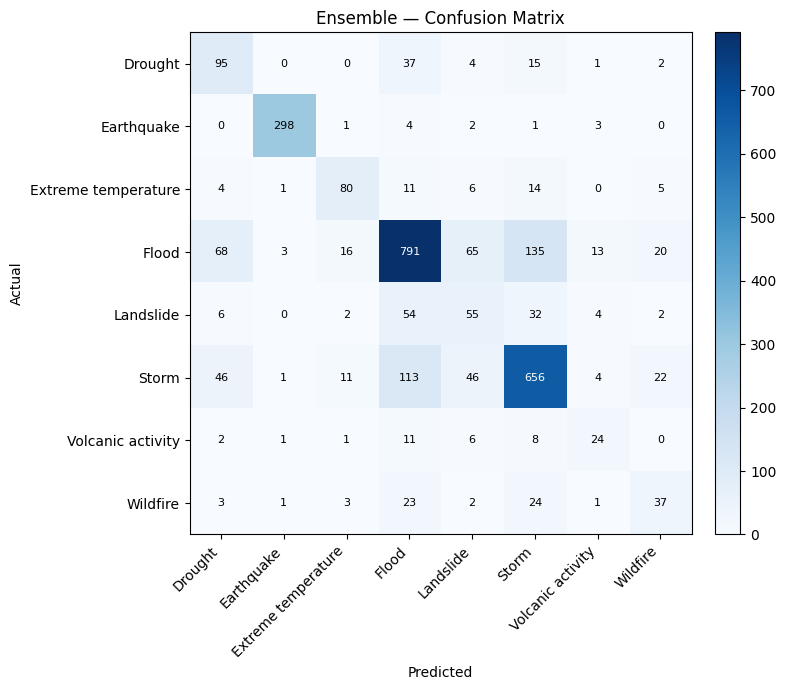

In [9]:
y_pred_ens = np.argmax(proba_ens, axis=1)
print(classification_report(y_test, y_pred_ens, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_test, y_pred_ens, labels=LABELS)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Ensemble — Confusion Matrix")
thresh = cm.max() / 2
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

### 8b · Per-class F1 comparison across models

,XGBoost,LightGBM,CatBoost,Ensemble
Drought,0.483,0.458,0.487,0.503
Earthquake,0.967,0.967,0.966,0.971
Extreme temperature,0.686,0.661,0.636,0.681
Flood,0.727,0.710,0.736,0.734
Landslide,0.312,0.305,0.350,0.323
Storm,0.731,0.709,0.730,0.735
Volcanic activity,0.442,0.385,0.379,0.466
Wildfire,0.462,0.346,0.413,0.407


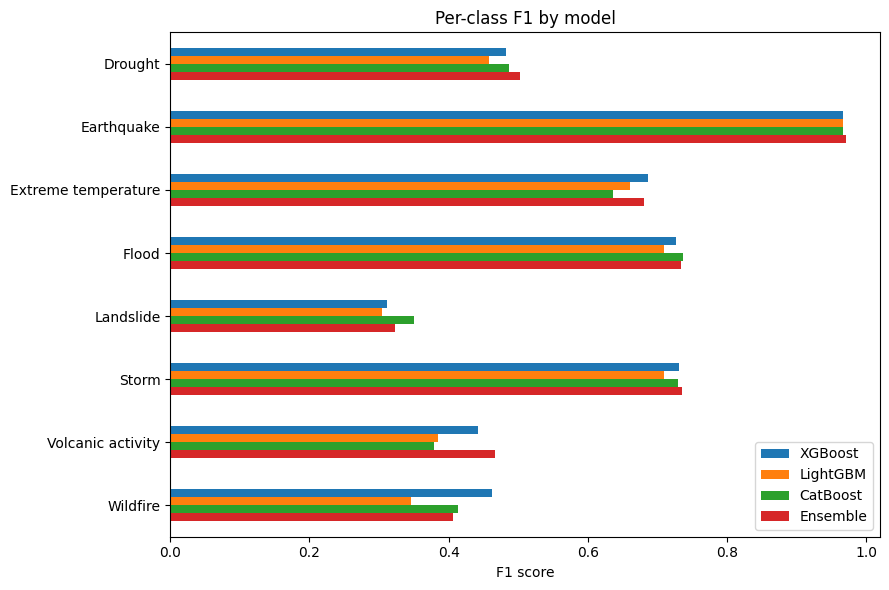

In [10]:
per_class = pd.DataFrame({
    "XGBoost":  f1_score(y_test, np.argmax(proba_xgb, 1), average=None, labels=LABELS, zero_division=0),
    "LightGBM": f1_score(y_test, np.argmax(proba_lgb, 1), average=None, labels=LABELS, zero_division=0),
    "CatBoost": f1_score(y_test, np.argmax(proba_cat, 1), average=None, labels=LABELS, zero_division=0),
    "Ensemble": f1_score(y_test, y_pred_ens,              average=None, labels=LABELS, zero_division=0),
}, index=CLASSES).round(3)
display(per_class)

ax = per_class.plot.barh(figsize=(9, 6))
ax.set_xlabel("F1 score"); ax.set_title("Per-class F1 by model"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9 · SHAP — global feature importance (XGBoost)

`TreeExplainer` on the XGBoost member; bars are `mean(|SHAP|)` over a test sample, averaged across classes.

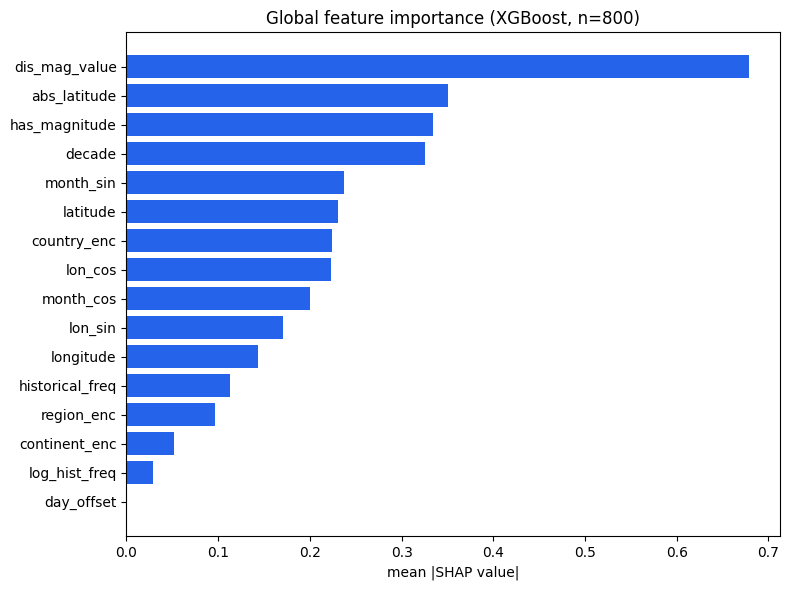

In [11]:
explainer = shap.TreeExplainer(clf_xgb)
n_shap = min(800, len(X_test))
sv = explainer.shap_values(X_test[:n_shap])
arr = np.array(sv)
if arr.ndim == 3:                                   # multiclass
    imp = np.abs(arr).mean(axis=(0, 1)) if arr.shape[0] == len(CLASSES) else np.abs(arr).mean(axis=(0, 2))
else:
    imp = np.abs(arr).mean(axis=0)

order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([FEATURE_NAMES[i] for i in order], imp[order], color="#2563eb")
ax.set_xlabel("mean |SHAP value|"); ax.set_title(f"Global feature importance (XGBoost, n={n_shap})")
plt.tight_layout(); plt.show()

## 10 · Impact regressors — 5 targets

Build the 5 raw targets (NaN preserved for unrecorded values). **Uninsured damages** = `Total Damages −
Insured Damages` where *both* are recorded (the project's deployed app derives it from a per-type
insurance ratio instead; here we train a genuine regressor on the observed difference).

In [12]:
TARGET_COLS = {
    "deaths":   "Total Deaths",
    "injuries": "No Injured",
    "affected": "No Affected",
    "damage":   "Total Damages ('000 US$)",
}
RF_TARGETS    = {"injuries", "affected"}        # RandomForest; the 3 monetary/count-heavy use XGBRegressor
MIN_TYPE_ROWS = 30                              # below this, a type falls back to the global model
ALL_TARGETS   = ["deaths", "injuries", "affected", "damage", "uninsured"]

def build_targets(frame):
    t = {k: pd.to_numeric(frame[col], errors="coerce").clip(lower=0).values
         for k, col in TARGET_COLS.items()}
    total = pd.to_numeric(frame["Total Damages ('000 US$)"], errors="coerce")
    insd  = pd.to_numeric(frame["Insured Damages ('000 US$)"], errors="coerce")
    unins = (total - insd).clip(lower=0)
    unins[total.isna() | insd.isna()] = np.nan   # both must be observed
    t["uninsured"] = unins.values
    return t

tgt_train = build_targets(train_df)
tgt_test  = build_targets(test_df)

cov = pd.DataFrame({
    "train_obs": {k: int(np.sum(~np.isnan(tgt_train[k]))) for k in ALL_TARGETS},
    "train_cov": {k: np.mean(~np.isnan(tgt_train[k]))      for k in ALL_TARGETS},
    "test_obs":  {k: int(np.sum(~np.isnan(tgt_test[k])))   for k in ALL_TARGETS},
}).round({"train_cov": 3})
display(cov)

,train_obs,train_cov,test_obs
deaths,8082,0.698,2015
injuries,3012,0.260,724
affected,6443,0.556,1599
damage,4177,0.361,1057
uninsured,731,0.063,175


In [13]:
def make_reg(key):
    if key in RF_TARGETS:
        return RandomForestRegressor(n_estimators=200, max_depth=10,
                                     min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)
    return XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

type_train = train_df["Disaster Type"].values
type_test  = test_df["Disaster Type"].values
global_reg   = {}
per_type_reg = {t: {} for t in CLASSES}

for key in ALL_TARGETS:
    raw = tgt_train[key]; obs = ~np.isnan(raw)
    g = make_reg(key); g.fit(X_train[obs], np.log1p(raw[obs])); global_reg[key] = g   # drop-null global
    n_pt = 0
    for t in CLASSES:
        sel = (type_train == t); rr = raw[sel]; o = ~np.isnan(rr)
        if o.sum() >= MIN_TYPE_ROWS:
            m = make_reg(key); m.fit(X_train[sel][o], np.log1p(rr[o]))
            per_type_reg[t][key] = m; n_pt += 1
    print(f"{key:<10} global on {obs.sum():>6,} obs rows | per-type models: {n_pt}/{len(CLASSES)}")

deaths     global on  8,082 obs rows | per-type models: 8/8


injuries   global on  3,012 obs rows | per-type models: 7/8


affected   global on  6,443 obs rows | per-type models: 8/8


damage     global on  4,177 obs rows | per-type models: 8/8


uninsured  global on    731 obs rows | per-type models: 4/8


### 10a · Regression scores (honest holdout — observed test rows only)

`err_factor = exp(MAE_log)`: the typical multiplicative error. e.g. 2.0 ⇒ predictions land within ~2× of
the truth on average. Reported for the production **per-type** design and a **global-only** baseline.

In [14]:
def route(key, dtype):
    return per_type_reg.get(dtype, {}).get(key) or global_reg[key]

def _predict_log(key, idx, use_per_type):
    if not use_per_type:
        return global_reg[key].predict(X_test[idx])
    out = np.empty(len(idx)); types = type_test[idx]
    for t in CLASSES:
        loc = np.where(types == t)[0]
        if len(loc):
            out[loc] = route(key, t).predict(X_test[idx][loc])
    return out

def regression_report(use_per_type):
    rows = []
    for key in ALL_TARGETS:
        raw = tgt_test[key]; obs = ~np.isnan(raw); idx = np.where(obs)[0]
        yt = raw[obs]
        logp = _predict_log(key, idx, use_per_type)
        yp = np.expm1(logp).clip(min=0)
        yt_log = np.log1p(yt)
        rows.append({
            "target":     key,
            "n_obs":      int(obs.sum()),
            "MAE_raw":    mean_absolute_error(yt, yp),
            "RMSE_raw":   np.sqrt(mean_squared_error(yt, yp)),
            "MedAE_raw":  median_absolute_error(yt, yp),
            "R2_raw":     r2_score(yt, yp),
            "MAE_log":    mean_absolute_error(yt_log, logp),
            "RMSE_log":   np.sqrt(mean_squared_error(yt_log, logp)),
            "R2_log":     r2_score(yt_log, logp),
            "expl_var_log": explained_variance_score(yt_log, logp),
            "err_factor": float(np.exp(mean_absolute_error(yt_log, logp))),
        })
    return pd.DataFrame(rows).set_index("target")

print("=== Per-type + drop-null regressors (production design) ===")
reg_pt = regression_report(True);  display(reg_pt.round(4))
print("=== Global-only baseline (single model per target) ===")
reg_gl = regression_report(False); display(reg_gl.round(4))

=== Per-type + drop-null regressors (production design) ===


,n_obs,MAE_raw,RMSE_raw,MedAE_raw,R2_raw,MAE_log,RMSE_log,R2_log,expl_var_log,err_factor
target,,,,,,,,,,
deaths,2015,1.411235e+03,3.144431e+04,15.1300,0.4942,1.0894,1.4534,0.3378,0.3379,2.9725
injuries,724,6.601799e+02,4.428982e+03,48.7887,0.0136,1.3821,1.7537,0.2064,0.2069,3.9835
affected,1599,1.027470e+06,9.308892e+06,16661.9521,0.0605,1.7444,2.1969,0.4041,0.4050,5.7225
damage,1057,6.813005e+05,4.915574e+06,77579.7183,0.0587,1.7985,2.3060,0.2185,0.2197,6.0404
uninsured,175,1.802785e+06,7.218273e+06,312511.7311,-0.0128,2.4692,3.8416,-0.0648,-0.0613,11.8125


=== Global-only baseline (single model per target) ===


,n_obs,MAE_raw,RMSE_raw,MedAE_raw,R2_raw,MAE_log,RMSE_log,R2_log,expl_var_log,err_factor
target,,,,,,,,,,
deaths,2015,1.926226e+03,4.413496e+04,13.7847,0.0036,1.0746,1.4532,0.3380,0.3381,2.9288
injuries,724,6.661645e+02,4.465201e+03,45.2758,-0.0026,1.3749,1.7497,0.2100,0.2110,3.9548
affected,1599,1.089493e+06,9.615323e+06,20415.3326,-0.0023,1.9083,2.3918,0.2937,0.2945,6.7413
damage,1057,6.737449e+05,5.008831e+06,76440.4219,0.0226,1.7523,2.2301,0.2691,0.2695,5.7676
uninsured,175,1.745092e+06,6.943025e+06,325226.5039,0.0630,2.4967,3.7850,-0.0337,-0.0333,12.1426


### 10b · Predicted vs actual (log scale) for each target

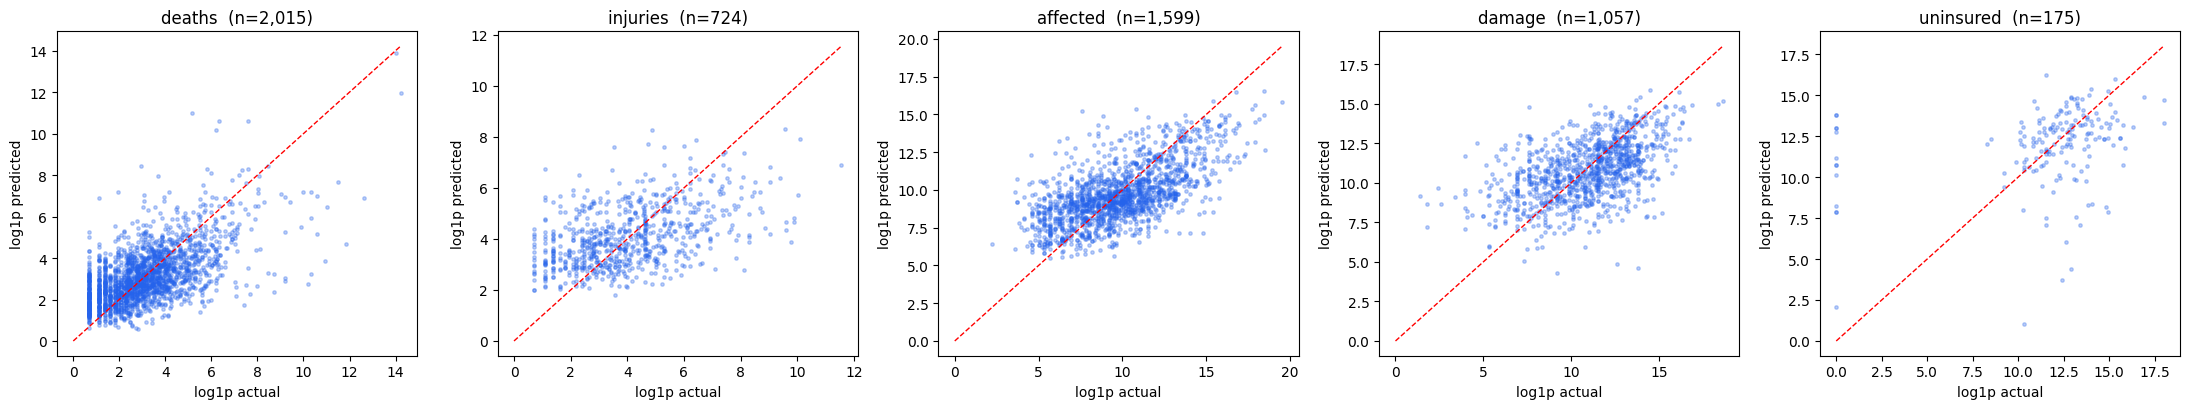

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, key in zip(axes, ALL_TARGETS):
    raw = tgt_test[key]; obs = ~np.isnan(raw); idx = np.where(obs)[0]
    yt = raw[obs]
    yp = np.expm1(_predict_log(key, idx, True)).clip(min=0)
    a, p = np.log1p(yt), np.log1p(yp)
    ax.scatter(a, p, s=6, alpha=0.3, color="#2563eb")
    lim = max(a.max(), p.max()) if len(a) else 1.0
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_title(f"{key}  (n={len(yt):,})"); ax.set_xlabel("log1p actual"); ax.set_ylabel("log1p predicted")
plt.tight_layout(); plt.show()

## 11 · End-to-end example: predicted type + 5 impact estimates vs actual

Eight random test events run through the full pipeline (ensemble type → route each impact regressor by the
**predicted** type). `None` actual = that impact value was not recorded in EM-DAT for that event.

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
sample_pos = rng.choice(len(test_df), size=8, replace=False)
recs = []
for i in sample_pos:
    feat   = X_test[[i]]
    featdf = X_test_df.iloc[[i]]
    proba  = WX*clf_xgb.predict_proba(feat) + WL*clf_lgb.predict_proba(featdf) + WC*clf_cat.predict_proba(feat)
    top    = CLASSES[int(np.argmax(proba[0]))]
    rec = {"country": test_df.loc[i, "Country"], "actual_type": test_df.loc[i, "Disaster Type"],
           "pred_type": top, "p": round(float(np.max(proba[0])), 3)}
    for key in ALL_TARGETS:
        pred = int(max(0, np.expm1(route(key, top).predict(feat)[0])))
        act  = tgt_test[key][i]
        rec[f"{key}_pred"]   = pred
        rec[f"{key}_actual"] = None if np.isnan(act) else int(act)
    recs.append(rec)
display(pd.DataFrame(recs))

,country,actual_type,pred_type,p,deaths_pred,deaths_actual,injuries_pred,injuries_actual,affected_pred,affected_actual,damage_pred,damage_actual,uninsured_pred,uninsured_actual
0,Turkey,Earthquake,Earthquake,0.996,255,27.0,613,NaN,41443,NaN,7562,NaN,3088002,None
1,Poland,Extreme temperature,Extreme temperature,0.992,45,21.0,474,NaN,18445,NaN,25626,NaN,1677,None
2,Namibia,Flood,Drought,0.760,130,NaN,30,NaN,545207,2502.0,67735,NaN,96255,None
3,China,Flood,Landslide,0.339,82,22.0,47,NaN,2039,35000.0,33980,12000.0,1977278,None
4,Afghanistan,Flood,Flood,0.975,26,20.0,34,NaN,4950,9500.0,15487,NaN,264959,None
5,Taiwan (Province of China),Earthquake,Earthquake,0.983,79,2746.0,337,6004.0,8927,NaN,73818,NaN,2123346,None
6,Paraguay,Storm,Storm,0.381,3,NaN,23,NaN,6360,47655.0,3161,NaN,11888,None
7,Iran (Islamic Republic of),Earthquake,Earthquake,0.998,3021,1360.0,1123,NaN,33149,NaN,68721,NaN,269735,None


## 12 · Summary

In [17]:
ens = clf_metrics.loc["Ensemble"]
print("CLASSIFIER (soft-voting ensemble, holdout):")
print(f"  Accuracy      {ens['accuracy']:.4f}")
print(f"  Macro F1      {ens['f1_macro']:.4f}")
print(f"  Weighted F1   {ens['f1_weighted']:.4f}")
print(f"  ROC-AUC (ovr) {ens['roc_auc_ovr_macro']:.4f} macro")
print(f"  Cohen kappa   {ens['cohen_kappa']:.4f}   Matthews CC {ens['matthews_cc']:.4f}")
print()
print("IMPACT REGRESSORS (per-type, honest holdout — err_factor = typical x-error):")
for key in ALL_TARGETS:
    r = reg_pt.loc[key]
    print(f"  {key:<10} n={int(r['n_obs']):>5,}  R2_log={r['R2_log']:+.3f}  err_factor={r['err_factor']:.2f}x")
print()
print("Train/test split: %d / %d  (stratified, random_state=%d)" % (len(train_df), len(test_df), RANDOM_STATE))
print("All scores above are computed on the held-out test split of the TRAIN dataset only.")

CLASSIFIER (soft-voting ensemble, holdout):
  Accuracy      0.7030
  Macro F1      0.6024
  Weighted F1   0.7077
  ROC-AUC (ovr) 0.9257 macro
  Cohen kappa   0.6014   Matthews CC 0.6020

IMPACT REGRESSORS (per-type, honest holdout — err_factor = typical x-error):
  deaths     n=2,015  R2_log=+0.338  err_factor=2.97x
  injuries   n=  724  R2_log=+0.206  err_factor=3.98x
  affected   n=1,599  R2_log=+0.404  err_factor=5.72x
  damage     n=1,057  R2_log=+0.218  err_factor=6.04x
  uninsured  n=  175  R2_log=-0.065  err_factor=11.81x

Train/test split: 11580 / 2896  (stratified, random_state=42)
All scores above are computed on the held-out test split of the TRAIN dataset only.
